In [ ]:
import random, math, time, json, os
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. INFORMAÇÕES DOS ITENS E VALORES DO LEILÃO
# =============================================================================
print("=" * 70)
print("🎯 LEILÃO DE CAVALOS - PROCESSO DE DECISÃO DE MARKOV")
print("=" * 70)

class Item:
    def __init__(self, name, valor_mensurado, preco_inicial_fixo):
        self.name = name
        self.valor_mensurado = valor_mensurado
        self.preco_inicial_fixo = preco_inicial_fixo
    def __repr__(self):
        return f"{self.name} (valor: {self.valor_mensurado}, preço inicial: {self.preco_inicial_fixo})"

# Itens com PREÇOS FIXOS
base_items = [
    Item('Ardentia', 3000, 1000),
    Item('Velora', 7000, 2500),
    Item('Luminara', 10000, 4000)
]

# Configurações do leilão
INCREMENTO_MINIMO = 500
ORCAMENTO_INICIAL = 20000

print("\n🏇 ITENS DO LEILÃO (PREÇOS FIXOS):")
print("-" * 50)
for i, item in enumerate(base_items, 1):
    print(f"  {i}. {item.name:10} | Valor: {item.valor_mensurado:5} Bari | Preço Inicial: {item.preco_inicial_fixo:4} Bari")

print(f"\n⚙️  CONFIGURAÇÕES DO LEILÃO:")
print("-" * 30)
print(f"  • Incremento mínimo: {INCREMENTO_MINIMO} Bari")
print(f"  • Incremento aleatório: ≥ {INCREMENTO_MINIMO} Bari")
print(f"  • Orçamento inicial: {ORCAMENTO_INICIAL} Bari")
print(f"  • Episódios: 10")
print(f"  • Passos máximos por episódio: 50")

print("\n" + "=" * 70)
print("📊 PROCESSO DE DECISÃO DE MARKOV (MDP)")
print("=" * 70)
print("🔹 Estados: (item_atual, lance_atual, budget_agente, budget_oponente)")
print("🔹 Ações: {None (passar), aumentar lance}")
print("🔹 Recompensas: +valor_item (se arrematar), -lance_pago (custo)")
print("🔹 Transições: definidas pelo ambiente + oponente")

# =============================================================================
# 2. LOGICA - MDP IMPLEMENTADO
# =============================================================================

class Oponente:
    def __init__(self, budget, limit_factor=2.0):
        """
        Classe que representa o oponente do leilão.
        - budget: orçamento total disponível.
        - limit_factor: fator multiplicador do valor mensurado que define o limite máximo de lance.
        """
        self.budget = budget
        self.budget_inicial = budget
        self.limit_factor = limit_factor

    def decide(self, current_bid, item, min_increment):
        """
        Decide o próximo lance do oponente.
        O oponente sobe lances de forma determinística até atingir o limite
        (limit_factor × valor_mensurado) ou seu orçamento.
        Quando atinge o limite, ele desiste (retorna None).
        """
        limit = int(self.limit_factor * item.valor_mensurado)


        if current_bid >= limit:
            return None


        next_bid = current_bid + min_increment


        if next_bid > limit or next_bid > self.budget:
            return None


        return next_bid


class AgenteAleatorio:
    def __init__(self, budget):
        self.budget = budget
        self.budget_inicial = budget
        self.history = []
        self.acquired = []

    def act(self, current_bid, item, min_increment):
        estado = {
            'item_nome': item.name,
            'item_valor': item.valor_mensurado,
            'preco_inicial_fixo': item.preco_inicial_fixo,
            'lance_atual': current_bid,
            'budget_agente': self.budget,
            'min_increment': min_increment,
            'pode_dar_lance': current_bid + min_increment <= self.budget
        }

        if current_bid + min_increment > self.budget:
            acao = None
        elif random.random() < 0.3:
            acao = None
        else:
            k = random.randint(1, 4)
            incremento_aleatorio = k * min_increment
            new_bid = current_bid + incremento_aleatorio
            if new_bid > self.budget:
                new_bid = self.budget
            acao = new_bid

        self.history.append({
            'estado': estado,
            'acao': acao,
            'timestamp': time.time()
        })

        return acao

class AmbienteLeilao:
    def __init__(self, items, agente, oponente, budget=20000, min_increment=500):
        self.items = list(items)
        self.agente = agente
        self.oponente = oponente
        self.budget = budget
        self.min_increment = min_increment
        self.current_item = None
        self.current_bid = 0
        self.highest_bidder = None
        self.history = []

    def reset_for_item(self, item):
        self.current_item = item
        # LANCE INICIAL EXATAMENTE O PREÇO FIXO
        self.current_bid = item.preco_inicial_fixo
        self.highest_bidder = None
        self.incremento_atual = max(INCREMENTO_MINIMO, random.randint(1, 3) * INCREMENTO_MINIMO)

        return {
            'item': item.name,
            'valor_estimado': item.valor_mensurado,
            'preco_inicial_fixo': item.preco_inicial_fixo,
            'lance_atual': self.current_bid,
            'incremento_atual': self.incremento_atual
        }

    def step(self, action_by_agent):
        info = {
            'item': self.current_item.name,
            'valor_estimado': self.current_item.valor_mensurado,
            'preco_inicial_fixo': self.current_item.preco_inicial_fixo,
            'incremento_atual': self.incremento_atual,
            'lance_atual_before': self.current_bid,
            'agent_bid': action_by_agent,
            'opponent_bid': None,
            'arrematou_agente': False,
            'arrematou_oponente': False,
            'oponente_desistiu': False,
            'recompensa_agente': 0,
            'recompensa_oponente': 0,
            'vetor_estado': {
                'item': self.current_item.name,
                'valor_item': self.current_item.valor_mensurado,
                'preco_inicial_fixo': self.current_item.preco_inicial_fixo,
                'lance_atual': self.current_bid,
                'incremento_atual': self.incremento_atual,
                'budget_agente': self.agente.budget,
                'budget_oponente': self.oponente.budget,
                'highest_bidder': self.highest_bidder
            }
        }

        # SE O AGENTE PASSA E OPONENTE É O ÚLTIMO LANCE, OPONENTE ARREMATA
        if action_by_agent is None and self.highest_bidder == 'oponente':
            info['arrematou_oponente'] = True
            info['recompensa_oponente'] = self.current_item.valor_mensurado - self.current_bid
            self.oponente.budget -= self.current_bid
            self.oponente.acquired.append((self.current_item.name, self.current_bid, self.current_item.valor_mensurado))
            info['lance_atual_after'] = self.current_bid
            self.history.append(info)
            return info

        # SE O AGENTE PASSA E NINGUÉM DEU LANCE AINDA, OPONENTE ARREMATA PELO PREÇO INICIAL
        if action_by_agent is None and self.highest_bidder is None:
            info['arrematou_oponente'] = True
            info['recompensa_oponente'] = self.current_item.valor_mensurado - self.current_bid
            self.oponente.budget -= self.current_bid
            self.oponente.acquired.append((self.current_item.name, self.current_bid, self.current_item.valor_mensurado))
            info['lance_atual_after'] = self.current_bid
            self.history.append(info)
            return info

        # AÇÃO DO AGENTE
        if action_by_agent is not None and action_by_agent > self.current_bid:
            diferenca = action_by_agent - self.current_bid
            k = max(1, int(math.ceil(diferenca / self.incremento_atual)))
            new_bid = self.current_bid + k * self.incremento_atual
            if new_bid > self.agente.budget:
                new_bid = self.agente.budget
            self.current_bid = new_bid
            self.highest_bidder = 'agente'

        # REAÇÃO DO OPONENTE
        opp_bid = self.oponente.decide(self.current_bid, self.current_item, self.incremento_atual)
        if opp_bid is not None:
            self.current_bid = opp_bid
            self.highest_bidder = 'oponente'
            info['opponent_bid'] = opp_bid
        else:
            # SE OPONENTE PASSA E AGENTE É O ÚLTIMO LANCE, AGENTE ARREMATA
            if self.highest_bidder == 'agente':
                info['arrematou_agente'] = True
                lucro = self.current_item.valor_mensurado - self.current_bid
                info['recompensa_agente'] = lucro
                self.agente.budget -= self.current_bid
                self.agente.acquired.append((self.current_item.name, self.current_bid, self.current_item.valor_mensurado))
            elif self.highest_bidder == 'oponente':
                #  por segurança
                info['arrematou_oponente'] = True
                lucro = self.current_item.valor_mensurado - self.current_bid
                info['recompensa_oponente'] = lucro
                self.oponente.budget -= self.current_bid
                self.oponente.acquired.append((self.current_item.name, self.current_bid, self.current_item.valor_mensurado))
            else:
                # Ambos passaram desde o início
                info['oponente_desistiu'] = True

        info['lance_atual_after'] = self.current_bid
        self.history.append(info)
        return info

def run_episode(env, max_steps=50, verbose=True):
    passos = 0
    items = env.items.copy()
    random.shuffle(items)
    agente = env.agente
    oponente = env.oponente

    # Reinicia as aquisições a cada episódio
    agente.acquired = []
    oponente.acquired = []
    agente.budget = agente.budget_inicial
    oponente.budget = oponente.budget_inicial

    for item in items:
        if passos >= max_steps:
            if verbose:
                print(f"⏹️  Máximo de {max_steps} passos atingido!")
            break

        info_inicial = env.reset_for_item(item)
        round_steps = 0

        if verbose:
            print(f"\n{'🚀 NOVO ITEM ':^50}")
            print(f"🏇 Cavalo: {item.name}")
            print(f"💰 Valor: {item.valor_mensurado} Bari")
            print(f"🎯 Preço inicial: {item.preco_inicial_fixo} Bari")
            print(f"📈 Incremento: {env.incremento_atual} Bari")
            print("-" * 50)

        item_arrematado = False

        while not item_arrematado:
            if passos >= max_steps:
                break

            agent_action = agente.act(env.current_bid, env.current_item, env.incremento_atual)
            info = env.step(agent_action)
            passos += 1
            round_steps += 1

            if verbose:
                status_agente = f"✅ Oferece {info['agent_bid']}" if info['agent_bid'] else "❌ Passa"

                #  STATUS PRECISOS
                if info['arrematou_oponente']:
                    status_oponente = "🏆 Arrematou!"
                elif info['arrematou_agente']:
                    status_oponente = "🚫 Desistiu"
                elif info['opponent_bid'] is not None:
                    status_oponente = f"⚡ Oferece {info['opponent_bid']}"
                else:
                    status_oponente = "🚫 Passa"  # "Analisando" → "Passa"

                print(f"🔹 Passo {passos:2d} | Lance: {info['lance_atual_after']:4d} Bari | "
                      f"Agente: {status_agente:15} | Oponente: {status_oponente}")

            # VERIFICA SE ALGUÉM ARREMATOU
            if info['arrematou_agente']:
                if verbose:
                    print(f"\n🎉 AGENTE ARREMATOU! {env.current_item.name} por {info['lance_atual_after']} Bari")
                    print(f"💵 Orçamento agente: {agente.budget} Bari")
                    print(f"🏆 Recompensa agente: {info['recompensa_agente']} Bari")
                item_arrematado = True
                break

            if info['arrematou_oponente']:
                if verbose:
                    print(f"\n🔥 OPONENTE ARREMATOU! {env.current_item.name} por {info['lance_atual_after']} Bari")
                    print(f"💵 Orçamento oponente: {oponente.budget} Bari")
                    print(f"🏆 Recompensa oponente: {info['recompensa_oponente']} Bari")
                item_arrematado = True
                break

            # SE AMBOS PASSARAM DESDE O INÍCIO
            if info['agent_bid'] is None and info['opponent_bid'] is None and self.highest_bidder is None:
                if verbose:
                    print(f"\n🤝 AMBOS PASSARAM - {env.current_item.name} não foi arrematado")
                item_arrematado = True
                break

            if round_steps > 10:
                if verbose:
                    print(f"\n⏰ TEMPO ESGOTADO - {env.current_item.name}")
                item_arrematado = True
                break

        time.sleep(0.001)

    # CÁLCULOS FINAIS DO EPISÓDIO
    total_item_value_agente = sum(x[2] for x in agente.acquired)
    total_item_value_oponente = sum(x[2] for x in oponente.acquired)

    patrimonio_agente = total_item_value_agente + agente.budget
    patrimonio_oponente = total_item_value_oponente + oponente.budget

    result = {
        'agente': {
            'acquired': agente.acquired,
            'total_item_value': total_item_value_agente,
            'saldo': agente.budget,
            'patrimonio': patrimonio_agente,
            'recompensa_total': sum(item[2] - item[1] for item in agente.acquired)
        },
        'oponente': {
            'acquired': oponente.acquired,
            'total_item_value': total_item_value_oponente,
            'saldo': oponente.budget,
            'patrimonio': patrimonio_oponente,
            'recompensa_total': sum(item[2] - item[1] for item in oponente.acquired)
        },
        'passos': passos
    }
    return result



def make_environment(seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    items_fixos = [
        Item('Ardentia', 3000, 1000),
        Item('Velora', 7000, 2500),
        Item('Luminara', 10000, 4000)
    ]

    agente = AgenteAleatorio(budget=ORCAMENTO_INICIAL)
    oponente = Oponente(budget=ORCAMENTO_INICIAL, limit_factor=2.0)
    env = AmbienteLeilao(items_fixos, agente, oponente, budget=ORCAMENTO_INICIAL, min_increment=INCREMENTO_MINIMO)
    return env

# =============================================================================
# 3. EXECUÇÃO DA SIMULAÇÃO - 10 EPISÓDIOS
# =============================================================================

print("\n" + "=" * 70)
print("🎮 INICIANDO SIMULAÇÃO - 10 EPISÓDIOS")
print("=" * 70)

results = []
num_episodes = 10

for ep in range(num_episodes):
    print(f"\n{' EPISÓDIO ' + str(ep+1) + ' ':*^70}")

    env = make_environment(seed=None)
    res = run_episode(env, max_steps=50, verbose=True)
    results.append(res)

    print(f"\n📋 RESUMO DO EPISÓDIO {ep+1}:")
    print("-" * 40)
    print("👤 AGENTE:")
    print(f"   💰 Patrimônio: {res['agente']['patrimonio']:6} Bari")
    print(f"   💵 Saldo:       {res['agente']['saldo']:6} Bari")
    print(f"   🎯 Recompensa:  {res['agente']['recompensa_total']:6} Bari")
    print(f"   📦 Itens:       {len(res['agente']['acquired'])}")
    for item in res['agente']['acquired']:
        print(f"      🏇 {item[0]} - Pago: {item[1]} Bari")

    print("\n🤖 OPONENTE:")
    print(f"   💰 Patrimônio: {res['oponente']['patrimonio']:6} Bari")
    print(f"   💵 Saldo:       {res['oponente']['saldo']:6} Bari")
    print(f"   🎯 Recompensa:  {res['oponente']['recompensa_total']:6} Bari")
    print(f"   📦 Itens:       {len(res['oponente']['acquired'])}")
    for item in res['oponente']['acquired']:
        print(f"      🏇 {item[0]} - Pago: {item[1]} Bari")

    print(f"\n👣 Passos executados: {res['passos']}")

print("\n" + "=" * 70)
print("✅ LEILÃO FINALIZADO!")
print("=" * 70)



🎯 LEILÃO DE CAVALOS - PROCESSO DE DECISÃO DE MARKOV

🏇 ITENS DO LEILÃO (PREÇOS FIXOS):
--------------------------------------------------
  1. Ardentia   | Valor:  3000 Bari | Preço Inicial: 1000 Bari
  2. Velora     | Valor:  7000 Bari | Preço Inicial: 2500 Bari
  3. Luminara   | Valor: 10000 Bari | Preço Inicial: 4000 Bari

⚙️  CONFIGURAÇÕES DO LEILÃO:
------------------------------
  • Incremento mínimo: 500 Bari
  • Incremento aleatório: ≥ 500 Bari
  • Orçamento inicial: 20000 Bari
  • Episódios: 10
  • Passos máximos por episódio: 50

📊 PROCESSO DE DECISÃO DE MARKOV (MDP)
🔹 Estados: (item_atual, lance_atual, budget_agente, budget_oponente)
🔹 Ações: {None (passar), aumentar lance}
🔹 Recompensas: +valor_item (se arrematar), -lance_pago (custo)
🔹 Transições: definidas pelo ambiente + oponente

🎮 INICIANDO SIMULAÇÃO - 10 EPISÓDIOS

***************************** EPISÓDIO 1 *****************************

                   🚀 NOVO ITEM                    
🏇 Cavalo: Velora
💰 Valor: 7000 B


📊 RELATÓRIO DE DESEMPENHO - AGENTE vs OPONENTE


/tmp/ipython-input-170854851.py:65: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-170854851.py:65: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-170854851.py:65: UserWarning: Glyph 127943 (\N{HORSE RACING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-170854851.py:65: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


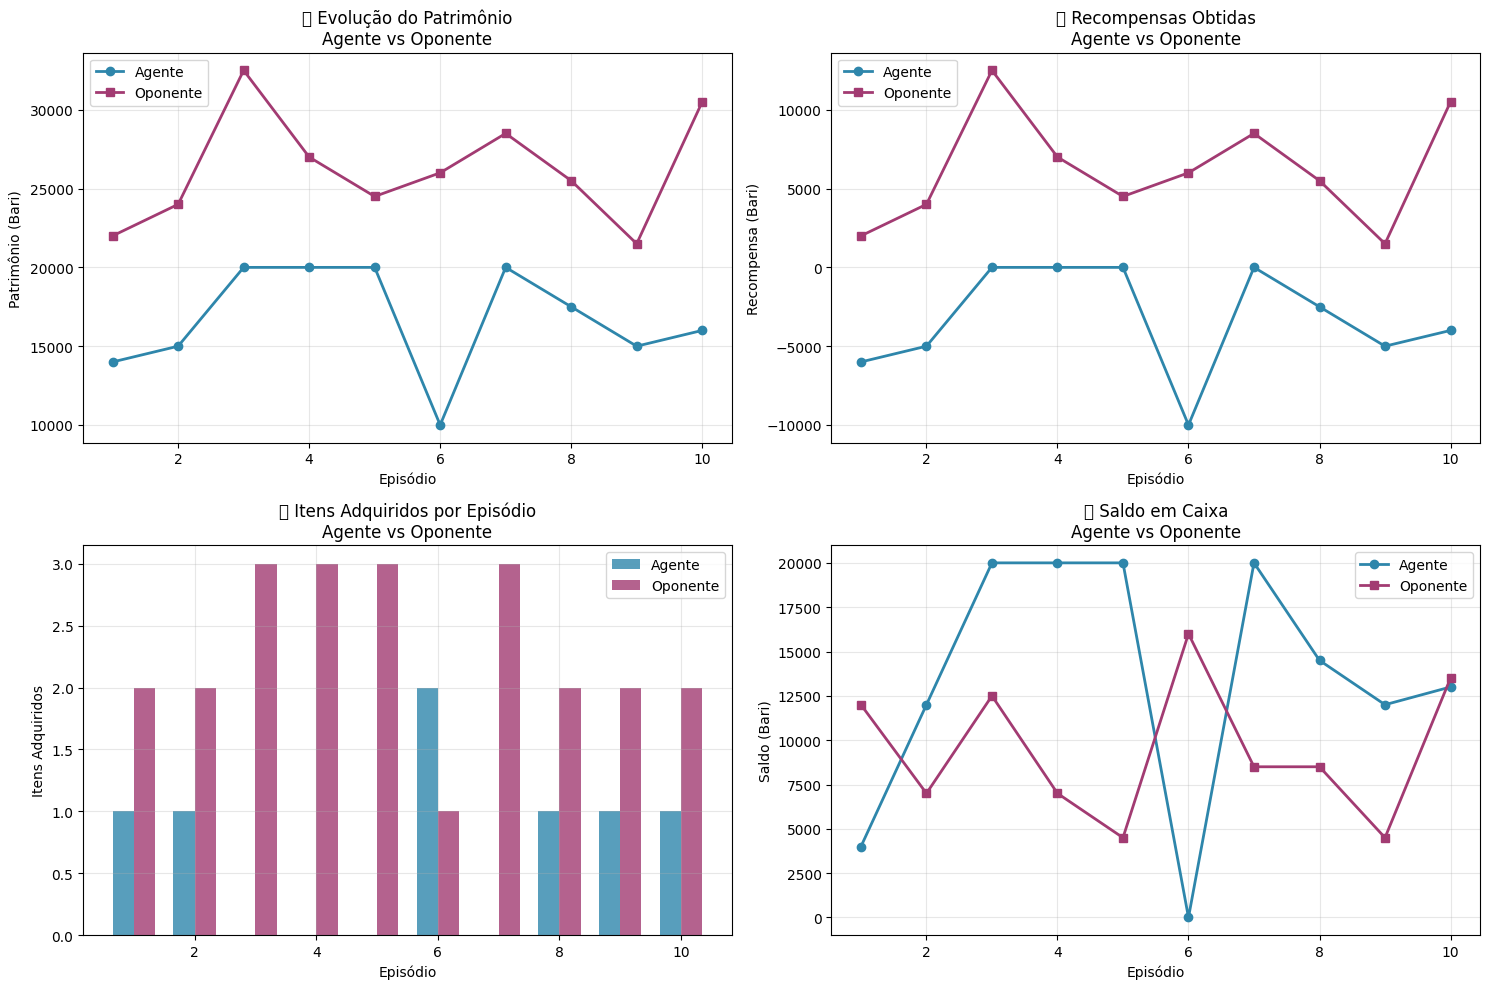

In [ ]:
# =============================================================================
# 4. ANÁLISE DOS RESULTADOS - GRÁFICOS PARA AMBOS
# =============================================================================

print("\n" + "=" * 70)
print("📊 RELATÓRIO DE DESEMPENHO - AGENTE vs OPONENTE")
print("=" * 70)

# Preparando dados para gráficos
patrimonios_agente = [r['agente']['patrimonio'] for r in results]
patrimonios_oponente = [r['oponente']['patrimonio'] for r in results]

recompensas_agente = [r['agente']['recompensa_total'] for r in results]
recompensas_oponente = [r['oponente']['recompensa_total'] for r in results]

itens_agente = [len(r['agente']['acquired']) for r in results]
itens_oponente = [len(r['oponente']['acquired']) for r in results]

# Gráfico 1: Patrimônio Comparativo
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(range(1, len(patrimonios_agente)+1), patrimonios_agente, marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Agente')
plt.plot(range(1, len(patrimonios_oponente)+1), patrimonios_oponente, marker='s', linewidth=2, markersize=6, color='#A23B72', label='Oponente')
plt.xlabel('Episódio')
plt.ylabel('Patrimônio (Bari)')
plt.title('💰 Evolução do Patrimônio\nAgente vs Oponente')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Recompensas Comparativas
plt.subplot(2, 2, 2)
plt.plot(range(1, len(recompensas_agente)+1), recompensas_agente, marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Agente')
plt.plot(range(1, len(recompensas_oponente)+1), recompensas_oponente, marker='s', linewidth=2, markersize=6, color='#A23B72', label='Oponente')
plt.xlabel('Episódio')
plt.ylabel('Recompensa (Bari)')
plt.title('🎯 Recompensas Obtidas\nAgente vs Oponente')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 3: Itens Adquiridos Comparativos
plt.subplot(2, 2, 3)
x = np.arange(1, len(itens_agente)+1)
width = 0.35
plt.bar(x - width/2, itens_agente, width, label='Agente', color='#2E86AB', alpha=0.8)
plt.bar(x + width/2, itens_oponente, width, label='Oponente', color='#A23B72', alpha=0.8)
plt.xlabel('Episódio')
plt.ylabel('Itens Adquiridos')
plt.title('🏇 Itens Adquiridos por Episódio\nAgente vs Oponente')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 4: Saldo Final Comparativo
plt.subplot(2, 2, 4)
saldos_agente = [r['agente']['saldo'] for r in results]
saldos_oponente = [r['oponente']['saldo'] for r in results]
plt.plot(range(1, len(saldos_agente)+1), saldos_agente, marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Agente')
plt.plot(range(1, len(saldos_oponente)+1), saldos_oponente, marker='s', linewidth=2, markersize=6, color='#A23B72', label='Oponente')
plt.xlabel('Episódio')
plt.ylabel('Saldo (Bari)')
plt.title('💵 Saldo em Caixa\nAgente vs Oponente')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Estatísticas Finais Comparativas
print(f"\n📈 ESTATÍSTICAS FINAIS COMPARATIVAS:")
print("-" * 45)
print(f"👤 AGENTE:")
print(f"   📊 Patrimônio médio: {np.mean(patrimonios_agente):.0f} Bari")
print(f"   🏇 Itens totais: {sum(itens_agente)}")
print(f"   💰 Melhor patrimônio: {max(patrimonios_agente)} Bari")

print(f"\n🤖 OPONENTE:")
print(f"   📊 Patrimônio médio: {np.mean(patrimonios_oponente):.0f} Bari")
print(f"   🏇 Itens totais: {sum(itens_oponente)}")
print(f"   💰 Melhor patrimônio: {max(patrimonios_oponente)} Bari")

print(f"\n⚔️  COMPARAÇÃO:")
print(f"   📈 Agente venceu: {sum(1 for i in range(10) if patrimonios_agente[i] > patrimonios_oponente[i])}/10 episódios")
print(f"   📉 Oponente venceu: {sum(1 for i in range(10) if patrimonios_oponente[i] > patrimonios_agente[i])}/10 episódios")
print(f"   🤝 Empates: {sum(1 for i in range(10) if patrimonios_agente[i] == patrimonios_oponente[i])}/10 episódios")



📈 ESTATÍSTICAS FINAIS COMPARATIVAS:
---------------------------------------------
👤 AGENTE:
   📊 Patrimônio médio: 16750 Bari
   🏇 Itens totais: 7
   💰 Melhor patrimônio: 20000 Bari

🤖 OPONENTE:
   📊 Patrimônio médio: 26200 Bari
   🏇 Itens totais: 23
   💰 Melhor patrimônio: 32500 Bari

⚔️  COMPARAÇÃO:
   📈 Agente venceu: 0/10 episódios
   📉 Oponente venceu: 10/10 episódios
   🤝 Empates: 0/10 episódios


In [ ]:
print(f"\n⚙️  CONFIGURAÇÃO UTILIZADA:")
print("-" * 30)
print(f"🏇 Cavalos: Ardentia (1000B), Velora (2500B), Luminara (4000B)")
print(f"📈 Incremento: Aleatório ≥{INCREMENTO_MINIMO}B")
print(f"💵 Orçamento: {ORCAMENTO_INICIAL}B para cada")
print(f"🎯 Política oponente: Ofertar até 2x valor mensurado")

print(f"\n🎉 SIMULAÇÃO FINALIZADA COM SUCESSO!")


⚙️  CONFIGURAÇÃO UTILIZADA:
------------------------------
🏇 Cavalos: Ardentia (1000B), Velora (2500B), Luminara (4000B)
📈 Incremento: Aleatório ≥500B
💵 Orçamento: 20000B para cada
🎯 Política oponente: Ofertar até 2x valor mensurado

🎉 SIMULAÇÃO FINALIZADA COM SUCESSO!
